Онищенко Геннадий 336883

Сложностей вроде не возникло.

Спасибо!

# 1. Считайте датасет из файла loan_prediction_dataset.csv


Импортируем все необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
import missingno as msno

Считываем датасет из файла `loan_prediction_dataset.csv `

In [2]:
df = pd.read_csv('/content/loan_prediction_dataset.csv')
df_first = pd.read_csv('/content/loan_prediction_dataset.csv')


# 2. Выведите основную информацию о датасете (info(), describe())


Без проблем `info` ->

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Получили основную инфу по типам данных в столбцах, количеству непустых строк, количество столбцов и строк.

describe ->

In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Получили основную инфу по числовым стобцам


# 3. Выведите таблицу пропусков по каждому столбцу:

абсолютное число

процент пропусков



1. Сначала с помощью .isna которая возвращает дата фрейм значений тру или фолс и .sum выведем количество пропусков по каждому столбцу

In [5]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


В кредитной истории пропусков больше всего))

Теперь общее число

In [6]:
df.isna().sum().sum()

np.int64(149)

149.
Теперь в процентном соотношении

In [7]:
(df.isna().sum() / len(df)) * 100

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


Можно чуть покрасивее

In [8]:
miss_pct = (df.isna().sum() / len(df) * 100).round(2)
miss_pct[miss_pct > 0].astype(str) + '%'

,0
Gender,2.12%
Married,0.49%
Dependents,2.44%
Self_Employed,5.21%
LoanAmount,3.58%
Loan_Amount_Term,2.28%
Credit_History,8.14%


И теперь в процентном соотношении количество пропусков от общего числа

In [9]:
total_cells = len(df) * len(df.columns)  # Всего ячеек
total_null = df.isna().sum().sum()
(total_null/total_cells)*100




np.float64(1.8667000751691305)

1,87%

# 4.Постройте визуализации пропусков:

матрицу пропусков

тепловую карту пропусков







1. Матрица пропусков. Белые полосы это пропуски, всё что серое - нормальные значения. По матрице можно сказать, что пропусков не много, заметны они только в кредитной истории и может быть в самозанятых.

<Axes: >

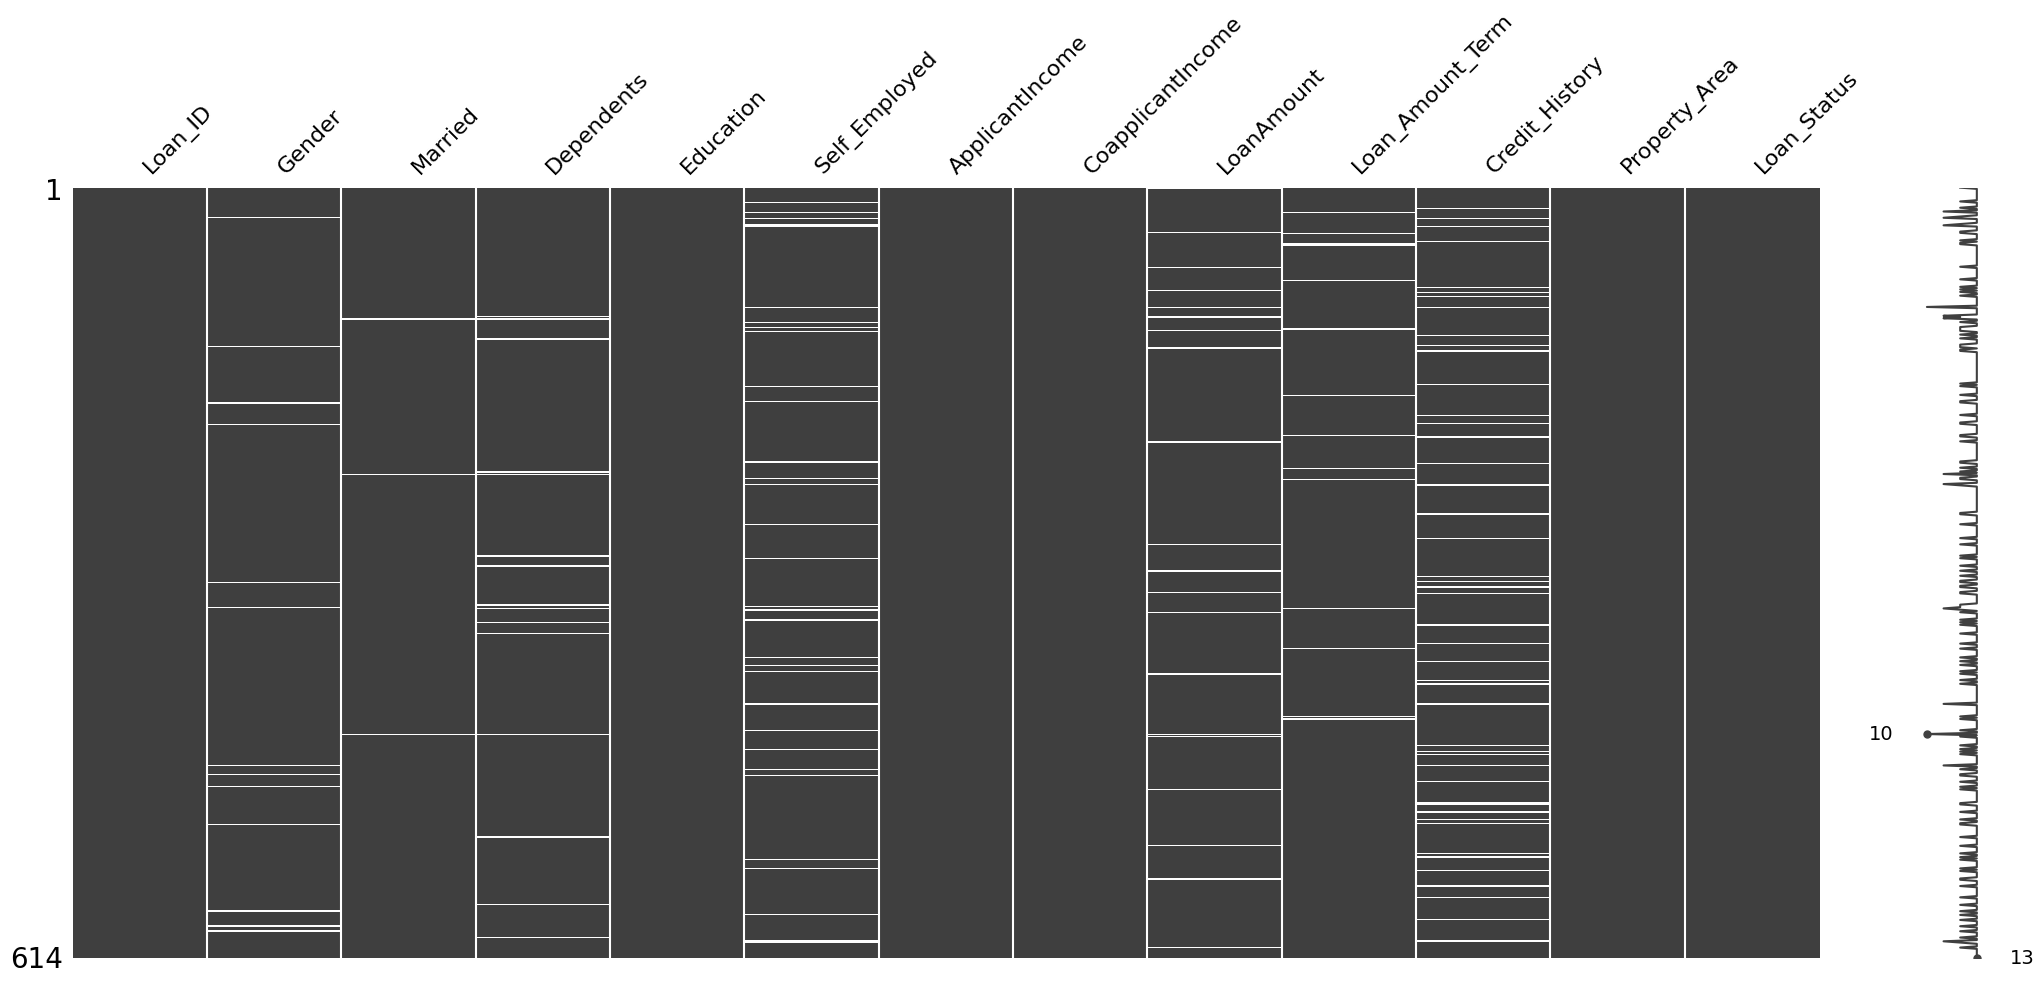

In [10]:
msno.matrix(df)

2. Тепловая карта. Тепловая карта показала бы нам кареляции между пропусками в разных столбцах, мы бы увидели выбросы на ней. Кареляцию мы видим только между depended и maried.

<Axes: >

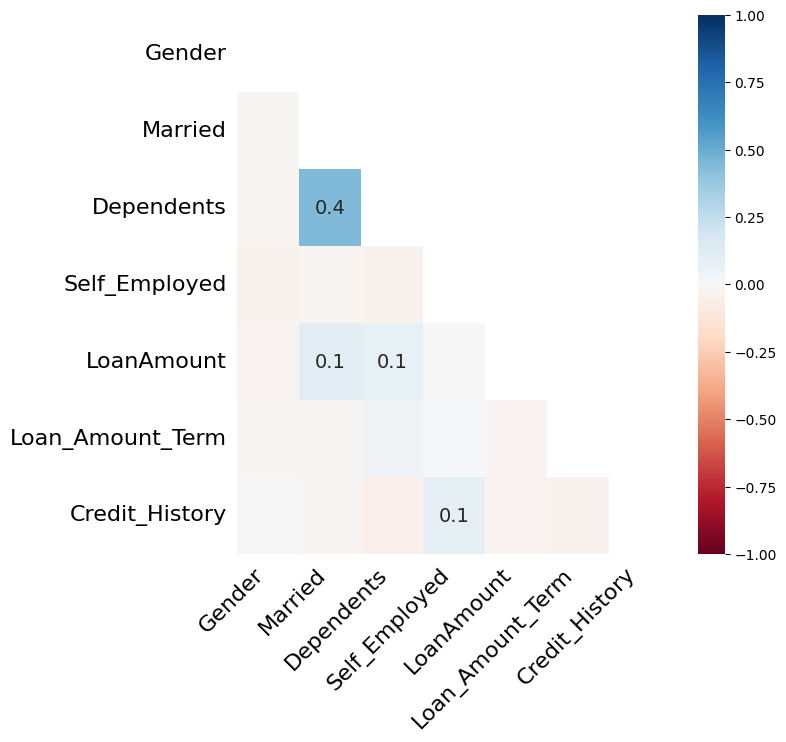

In [11]:
msno.heatmap(df, figsize=(7, 7))

# 5. Проинтерпретируйте полученные графики

Исходя из того что мы увидели на матрице и на тепловой карте можно сделать выводы что пропуски очень редкие и по большому счету не зависят друг от друга, из чего можно сделать вывод что они случайные. Для такого случая нам будет достаточно обычных методов заполнения типа моды.

# 6. Разделите признаки с пропусками на:

числовые

категориальные




In [12]:
has_na_columns = miss_pct.index
number_features = df[has_na_columns].select_dtypes(include=np.number).columns
text_features = df[has_na_columns].select_dtypes(include=['object', 'category']).columns

print("Числовые колонки с пропусками:", number_features)
print("Текстовые колонки с пропусками:", text_features)


Числовые колонки с пропусками: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')
Текстовые колонки с пропусками: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


классифицируем столбцы с пропусками на числовые и категориальные для выбора стратегии заполнения:` has_na_columns = miss_pct.index` берет названия столбцов где есть NaN, `df[has_na_columns]` отбираем только эти проблемные столбцы, `select_dtypes()` разделяем их — `np.number` находит числа, `'object','category'` находит текст/категории результат выводит списки. все разделено корректно, можно заполнять пропуски

# 7. Заполните пропуски (обоснуйте выбор метода для каждого типа признаков)


In [13]:
for c in number_features:
    df[c] = df[c].fillna(df[c].median())

для заполнения числовых пропусков использую медиану потому, что она не сдвинет общие числовые показатели и не создаст искажений. цикл `for col in number_features` заменяет все NaN в числовых столбцах на эту медиану, сохраняя реалистичное распределение данных.

In [14]:
for c in text_features:
    df[c] = df[c].fillna(df[c].mode()[0])

Для текстовых столбцов я использую моду, так как это самое популярное значение и при большом количестве данных заполнить пропуска корректно.

# 8. Проверьте, что пропуски заполнены корректно — 1 балл



<Axes: >

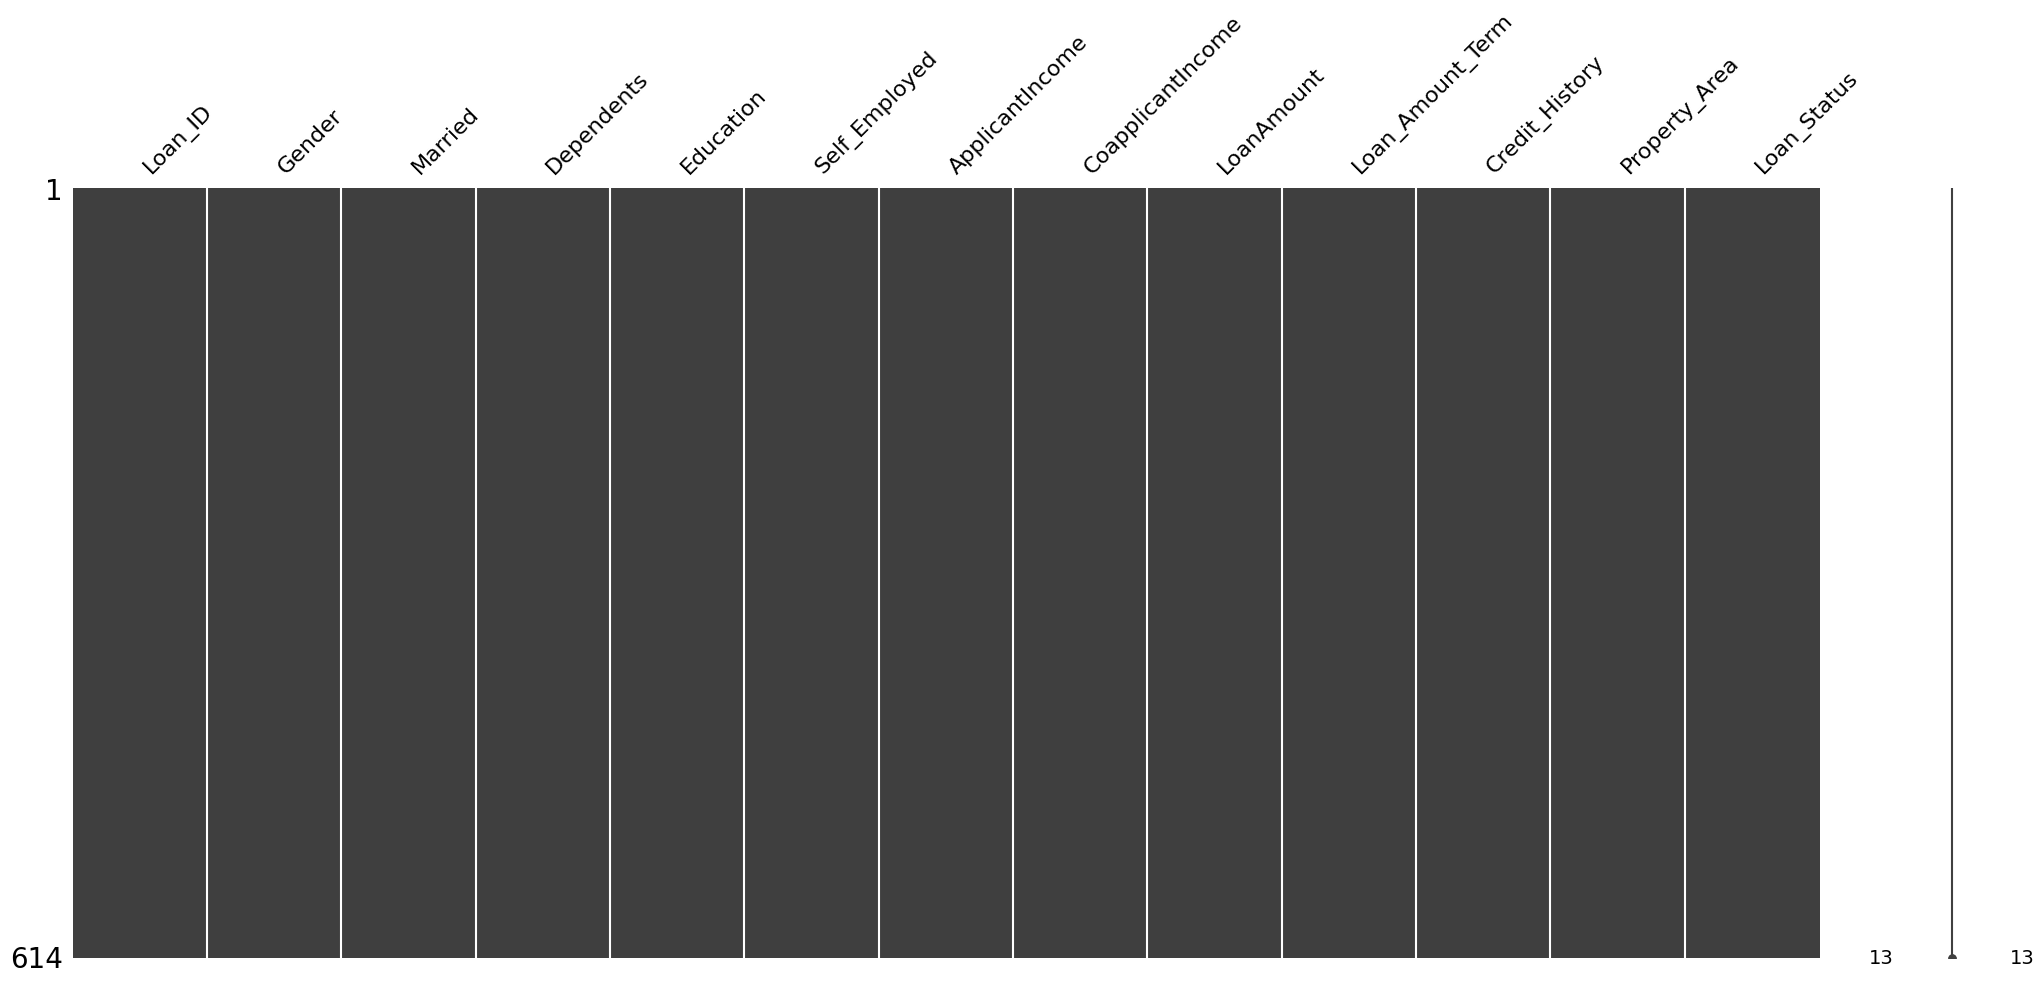

In [15]:
msno.matrix(df)

Пропусков больше нет, ура!
Теперь детально проверим

# 9. Покажите статистики до/после заполнения и кратко прокомментируйте изменения

In [16]:
print(df.describe())
print(df_first.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  614.000000        614.000000   
mean       5403.459283        1621.245798  145.752443        342.410423   
std        6109.041673        2926.248369   84.107233         64.428629   
min         150.000000           0.000000    9.000000         12.000000   
25%        2877.500000           0.000000  100.250000        360.000000   
50%        3812.500000        1188.500000  128.000000        360.000000   
75%        5795.000000        2297.250000  164.750000        360.000000   
max       81000.000000       41667.000000  700.000000        480.000000   

       Credit_History  
count      614.000000  
mean         0.855049  
std          0.352339  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         61

В столбцах гдек не было пропусков - ничего не изменилось. В столбце с большим количеством пропусков (кредитная история) уменьшилось std стандартное отклонение

In [17]:
print(df.select_dtypes(include=['object', 'category']).describe())
print("---------")
print(df_first.select_dtypes(include=['object', 'category']).describe())

         Loan_ID Gender Married Dependents Education Self_Employed  \
count        614    614     614        614       614           614   
unique       614      2       2          4         2             2   
top     LP002990   Male     Yes          0  Graduate            No   
freq           1    502     401        360       480           532   

       Property_Area Loan_Status  
count            614         614  
unique             3           2  
top        Semiurban           Y  
freq             233         422  
---------
         Loan_ID Gender Married Dependents Education Self_Employed  \
count        614    601     611        599       614           582   
unique       614      2       2          4         2             2   
top     LP002990   Male     Yes          0  Graduate            No   
freq           1    489     398        345       480           500   

       Property_Area Loan_Status  
count            614         614  
unique             3           2  
top     

Увеличилось число freq - количество раз когда встречается самое популярное значение.